# Monte Carlo Expectation Gradients (Shot Noise)

Goal: compute gradients of the Monte Carlo expectation over shot noise using explicit noise inputs and common random numbers (CRN).

We use:
- `FEL_sim_jax(theta, noise, noise_spec)` for one realization
- `mc_objective_jax(theta, noise_batch, noise_spec, loss_fn)` for expectation estimate
- `mc_value_and_grad_jax(...)` for value + gradient


In [5]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from zfel import sase1d

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


## 1) Base Parameters and Noise Spec


In [6]:
inp = dict(
    npart   = 512,                       # n-macro-particles per bucket 
    s_steps = 200,                      # n-sample points along bunch length
    z_steps = 200,                      # n-sample points along undulator
    energy  = 4313.34e6,                # electron energy [eV]
    eSpread = 0,                       # relative rms energy spread [1]
    emitN   = 1.2e-6,                    # normalized transverse emittance [m-rad]
    currentMax = 3900,                   # peak current [Ampere]
    beta = 26,                          # mean beta [meter]
    unduPeriod = 0.03,                 # undulator period [meter]
    unduK = np.full(200, 3.5) ,          # undulator parameter, K [1], array could taper. 
    unduL = 70,                         # length of undulator [meter]
    radWavelength=None,                 # Will calculate based on resonance condition for unduK[0]
    random_seed=31,                     # for reproducibility
    particle_position=np.genfromtxt('./data/SASE_particle_position.csv', delimiter=','), # or None   
    hist_rule='square-root',             # 'square-root' or 'sturges' or 'rice-rule' or 'self-design', number \                                       #  of intervals to generate the histogram of eta value in a bucket
    iopt='sase'
)

params_np = sase1d.params_calc(**inp)
params = {k: jnp.asarray(v) for k, v in params_np.items()}

noise_spec = sase1d.make_shot_noise_spec_from_params(
    params_np, npart=inp['npart'], s_steps=inp['s_steps'], iopt=inp['iopt']
)
noise_spec


{'npart': 512, 's_steps': 200, 'iopt': 'sase', 'M': 32, 'nb': 16}

## 2) Generate a CRN Noise Batch


In [7]:
N = 16
key = jax.random.PRNGKey(123)
noise_batch = sase1d.sample_shot_noise_batch_jax(key, noise_spec, N)

print('eta_randn batch shape:', noise_batch['eta_randn'].shape)
print('theta_rand batch shape:', noise_batch['theta_rand'].shape)


eta_randn batch shape: (16, 200, 16)
theta_rand batch shape: (16, 200, 16, 32)


## 3) One-Realization Differentiable Solve


In [8]:
noise0 = {
    'eta_randn': noise_batch['eta_randn'][0],
    'theta_rand': noise_batch['theta_rand'][0],
}
out0 = sase1d.FEL_sim_jax(params, noise0, noise_spec)
print('single-shot final power [W]:', float(out0['power_z'][-1]))


single-shot final power [W]: 14212898834.783054


## 4) Monte Carlo Objective and Gradient

Estimate expectation and gradient with fixed CRN batch:
\(\hat J(\theta)=\frac{1}{N}\sum_i f(F(\theta,\xi_i))\).


In [9]:
def loss_final_power(out):
    return out['power_z'][-1] / 1e9

J = sase1d.mc_objective_jax(params, noise_batch, noise_spec, loss_fn=loss_final_power)
J_val, J_grad = sase1d.mc_value_and_grad_jax(params, noise_batch, noise_spec, loss_fn=loss_final_power)

print('J_hat final power [GW]:', float(J))
print('value_and_grad value [GW]:', float(J_val))
print('grad kappa_1 shape:', J_grad['kappa_1'].shape)
print('||grad kappa_1||_2:', float(jnp.linalg.norm(J_grad['kappa_1'])))


J_hat final power [GW]: 16.501584176726965
value_and_grad value [GW]: 16.501584176726965
grad kappa_1 shape: (200,)
||grad kappa_1||_2: 89829886729155.72


## 5) Gradient of Expected Pulse-Energy-Like Objective


In [6]:
def loss_pulse_energy(out):
    return jnp.sum(out['power_s'][-1]) / 1e12

E_val, E_grad = sase1d.mc_value_and_grad_jax(params, noise_batch, noise_spec, loss_fn=loss_pulse_energy)
print('J_hat pulse-energy-like objective:', float(E_val))
print('||grad kappa_1||_2:', float(jnp.linalg.norm(E_grad['kappa_1'])))


J_hat pulse-energy-like objective: 3.4647244025099213
||grad kappa_1||_2: 80711679737856.0


## 6) Common Random Numbers Stability Demo


fixed CRN grad norms: [39567814033408.0, 39567814033408.0, 39567814033408.0, 39567814033408.0, 39567814033408.0]
varying seeds grad norms: [61961068871680.0, 25029425233920.0, 42332275605504.0, 17244621897728.0, 44507697512448.0]


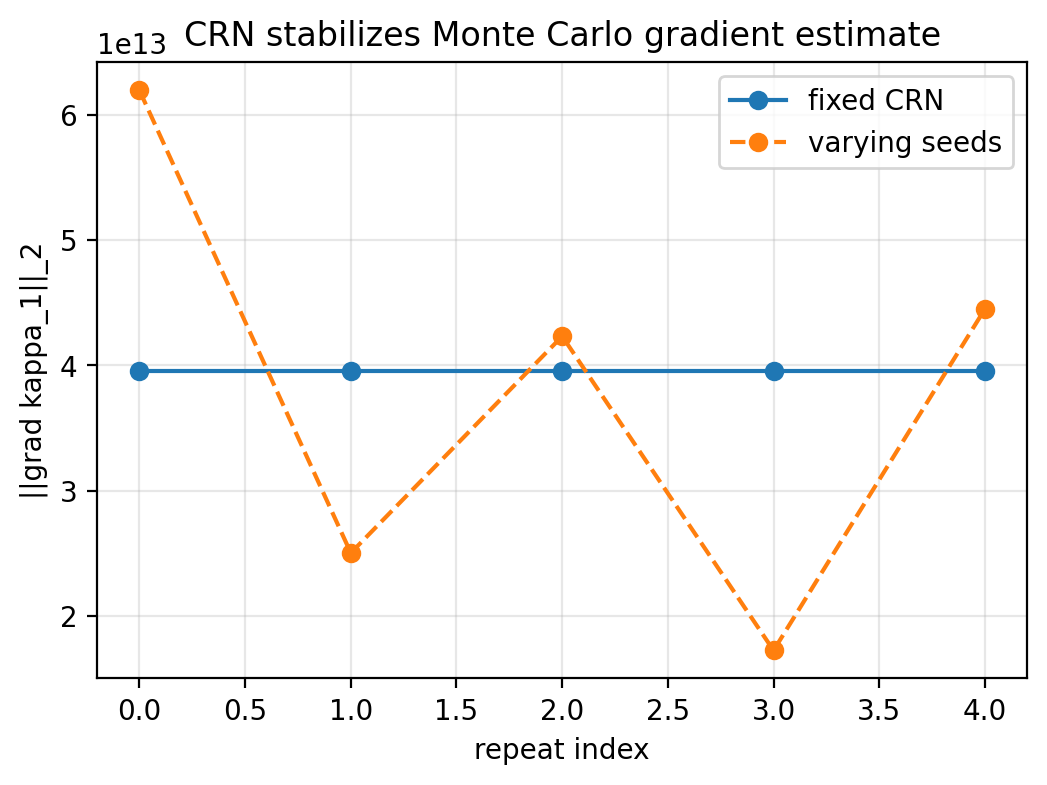

In [6]:
# Compare repeated estimates with fixed CRN vs changing keys
def eval_grad_norm(noise_batch_local):
    _, g = sase1d.mc_value_and_grad_jax(params, noise_batch_local, noise_spec, loss_fn=loss_final_power)
    return float(jnp.linalg.norm(g['kappa_1']))

fixed_vals = [eval_grad_norm(noise_batch) for _ in range(5)]

varying_vals = []
for i in range(5):
    nb_i = sase1d.sample_shot_noise_batch_jax(jax.random.PRNGKey(100 + i), noise_spec, N)
    varying_vals.append(eval_grad_norm(nb_i))

print('fixed CRN grad norms:', fixed_vals)
print('varying seeds grad norms:', varying_vals)

plt.figure(figsize=(6,4))
plt.plot(fixed_vals, 'o-', label='fixed CRN')
plt.plot(varying_vals, 'o--', label='varying seeds')
plt.ylabel('||grad kappa_1||_2')
plt.xlabel('repeat index')
plt.title('CRN stabilizes Monte Carlo gradient estimate')
plt.grid(alpha=0.3)
plt.legend()


## 7) Better Optimization Demo: Bounded Quadratic Taper With Smooth Start

This version keeps the control problem small and fixes two conditioning problems in the earlier demo:
- optimize only three variables: taper start, linear coefficient, and quadratic coefficient
- use a smooth differentiable gate near the taper start so the start position gets gradient signal
- keep the taper coefficients bounded and negative so the optimizer cannot choose an unrealistically large taper
- keep `K0` and the injected seed fixed during optimization
- maximize mean pulse energy on a fixed CRN batch

Two practical details matter:
- with exactly zero taper coefficients, the taper-start parameter is nearly invisible to the optimizer
- with unbounded polynomial coefficients, the optimizer often drives the taper much stronger than desired

So we initialize with a tiny taper and optimize bounded coefficients with a smooth turn-on.


In [ ]:
import math
import os

# Use a compact setup so the demo runs in a reasonable time.
opt_inp = dict(
    npart=96,
    s_steps=100,
    z_steps=100,
    energy=4313.34e6,
    eSpread=0.01,
    emitN=1.2e-6,
    currentMax=3400,
    beta=26,
    unduPeriod=0.03,
    unduK=3.5,
    unduL=70,
    radWavelength=None,
    random_seed=31,
    particle_position=None,
    hist_rule='square-root',
    iopt='sase',
    P0=1e3,
)

params_opt_np = sase1d.params_calc(**opt_inp)
params_opt = {k: jnp.asarray(v) for k, v in params_opt_np.items()}
noise_spec_opt = sase1d.make_shot_noise_spec_from_params(
    params_opt_np,
    npart=opt_inp['npart'],
    s_steps=opt_inp['s_steps'],
    iopt=opt_inp['iopt'],
)

# Common random numbers (fixed during optimization)
N_opt = 12
noise_batch_opt = sase1d.sample_shot_noise_batch_jax(
    jax.random.PRNGKey(123), noise_spec_opt, N_opt
)

z_steps_opt = opt_inp['z_steps']
z_grid = jnp.linspace(0.0, 1.0, z_steps_opt)
K0 = jnp.asarray(opt_inp['unduK'], dtype=jnp.float64)

# Constants
mc2 = sase1d.mc2
c = sase1d.c
e = sase1d.e
epsilon_0 = sase1d.epsilon_0

energy = jnp.asarray(opt_inp['energy'])
emitN = jnp.asarray(opt_inp['emitN'])
currentMax = jnp.asarray(opt_inp['currentMax'])
beta = jnp.asarray(opt_inp['beta'])
unduPeriod = jnp.asarray(opt_inp['unduPeriod'])
radWavelength_ref = params_opt['resWavelength']
P0 = jnp.asarray(opt_inp['P0'])

# Bessel approximations (JAX-differentiable)
def j0_series(x, n_terms=20):
    acc = jnp.zeros_like(x)
    for m in range(n_terms):
        acc = acc + ((-1.0) ** m) / (math.factorial(m) ** 2) * (x**2 / 4.0) ** m
    return acc


def j1_series(x, n_terms=20):
    acc = jnp.zeros_like(x)
    for m in range(n_terms):
        acc = acc + ((-1.0) ** m) / (math.factorial(m) * math.factorial(m + 1)) * (x / 2.0) ** (2 * m + 1)
    return acc


def inv_sigmoid(y):
    return jnp.log(y / (1.0 - y))


def theta_to_K_profile(theta):
    # theta = [taper_start_logit, linear_coeff_logit, quadratic_coeff_logit]
    # Keep the taper start in the later part of the undulator where tapering is usually meaningful.
    start_frac = 0.35 + 0.5 * jax.nn.sigmoid(theta[0])

    # Progress variable after taper start, normalized to [0, 1].
    u_raw = (z_grid - start_frac) / jnp.maximum(1.0 - start_frac, 1e-6)
    u = jnp.clip(u_raw, 0.0, 1.0)

    # Smooth gate avoids a dead gradient for taper_start near zero taper.
    gate_width = 0.04
    gate = jax.nn.sigmoid((z_grid - start_frac) / gate_width)

    # Bound the taper strengths and keep them negative.
    max_lin_drop = 0.18
    max_quad_drop = 0.12
    lin_coeff = -max_lin_drop * jax.nn.sigmoid(theta[1])
    quad_coeff = -max_quad_drop * jax.nn.sigmoid(theta[2])

    delta_K = gate * (lin_coeff * u + quad_coeff * u**2)
    K_profile = K0 + delta_K
    return K_profile, start_frac, lin_coeff, quad_coeff


def params_from_K_profile(K_profile):
    x = K_profile**2 / (4 + 2 * K_profile**2)
    unduJJ = j0_series(x) - j1_series(x)

    gamma0 = energy / mc2
    sigmaX2 = emitN * beta / gamma0

    kappa_1 = e * K_profile * unduJJ / 4 / epsilon_0 / gamma0
    Kai = e * K_profile * unduJJ / (2 * gamma0**2 * mc2 * e)
    density = currentMax / (e * c * 2 * jnp.pi * sigmaX2)

    resWavelength = unduPeriod * (1 + K_profile[0] ** 2 / 2.0) / (2 * gamma0**2)
    Pbeam = energy * currentMax
    coopLength = resWavelength / unduPeriod

    z0 = jnp.asarray(opt_inp['unduL'])
    delt = z0 / z_steps_opt
    dels = delt

    E02 = density * kappa_1[0] * P0 / Pbeam / Kai[0]
    gbar = resWavelength / radWavelength_ref - 1.0
    Ns = currentMax * z0 / unduPeriod / z_steps_opt * resWavelength / c / e
    deta = jnp.sqrt((1 + 0.5 * K_profile[0] ** 2) / (1 + 0.5 * K_profile**2)) - 1

    p = dict(params_opt)
    p.update(
        {
            'kappa_1': kappa_1,
            'Kai': Kai,
            'density': density,
            'resWavelength': resWavelength,
            'coopLength': coopLength,
            'delt': delt,
            'dels': dels,
            'E02': E02,
            'gbar': gbar,
            'Ns': Ns,
            'deta': deta,
        }
    )
    return p


def pulse_energy_loss(output):
    return jnp.sum(output['power_s'][-1]) / 1e12


def mc_objective_from_theta(theta, lambda_var=0.0, lambda_amp=0.01):
    K_profile, start_frac, lin_coeff, quad_coeff = theta_to_K_profile(theta)
    p = params_from_K_profile(K_profile)

    energies = jax.vmap(
        lambda noise_i: pulse_energy_loss(sase1d.FEL_sim_jax(p, noise_i, noise_spec_opt))
    )(noise_batch_opt)

    mean_E = jnp.mean(energies)
    var_E = jnp.var(energies)
    amp_pen = lin_coeff**2 + quad_coeff**2
    obj = mean_E - lambda_var * var_E - lambda_amp * amp_pen
    return obj, (mean_E, var_E, K_profile, start_frac, lin_coeff, quad_coeff)


# Adam optimization over [taper_start, linear_coeff, quadratic_coeff].
# Initialize with a tiny taper so taper_start sees gradient signal immediately.
theta = jnp.array(
    [
        0.0,
        inv_sigmoid(0.01 / 0.18),
        inv_sigmoid(0.002 / 0.12),
    ],
    dtype=jnp.float64,
)

n_iter = 120
lr = 0.05
b1, b2 = 0.9, 0.999
eps = 1e-8
m = jnp.zeros_like(theta)
v = jnp.zeros_like(theta)

obj_hist = []
mean_hist = []
var_hist = []
start_hist = []

obj0, aux0 = mc_objective_from_theta(theta)
K_init = aux0[2]
start_init = aux0[3]

for t in range(1, n_iter + 1):
    (obj, aux), g = jax.value_and_grad(mc_objective_from_theta, has_aux=True)(theta)

    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * (g * g)
    m_hat = m / (1 - b1**t)
    v_hat = v / (1 - b2**t)
    theta = theta + lr * m_hat / (jnp.sqrt(v_hat) + eps)

    obj_hist.append(float(obj))
    mean_hist.append(float(aux[0]))
    var_hist.append(float(aux[1]))
    start_hist.append(float(aux[3] * (z_steps_opt - 1)))

objF, auxF = mc_objective_from_theta(theta)
K_final = auxF[2]
start_final = auxF[3]

print('Initial expected pulse energy:', float(aux0[0]))
print('Final expected pulse energy:  ', float(auxF[0]))
print('Improvement ratio (final/initial):', float(auxF[0] / aux0[0]))
print('Initial taper start [z-step]:', float(start_init * (z_steps_opt - 1)))
print('Final taper start [z-step]:  ', float(start_final * (z_steps_opt - 1)))
print('Optimized bounded linear coefficient:   ', float(auxF[4]))
print('Optimized bounded quadratic coefficient:', float(auxF[5]))


Initial expected pulse energy: 0.0470214959548117
Final expected pulse energy:   0.04408806010727465
Improvement ratio (final/initial): 0.9376150037770785
Initial taper start [z-step]: 72.37479928437048
Final taper start [z-step]:   68.91424734990058
Optimized [linear, quadratic] coefficients: [-0.24756929 -0.18966497]


In [14]:
z_idx = np.arange(z_steps_opt)
start_line = float(start_final * (z_steps_opt - 1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(z_idx, np.asarray(K_init), label='initial K')
ax[0].plot(z_idx, np.asarray(K_final), '--', label='optimized K')
ax[0].axvline(start_line, color='k', linestyle=':', alpha=0.5, label='optimized taper start')
ax[0].set_xlabel('z-step index')
ax[0].set_ylabel('K')
ax[0].set_title('Bounded Quadratic Taper: Initial vs Optimized')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(mean_hist, label='expected pulse energy')
ax[1].plot(var_hist, '--', label='pulse-energy variance')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('Objective components (scaled)')
ax[1].set_title('Optimization History')
ax[1].grid(alpha=0.3)
ax[1].legend()

fig.tight_layout()

os.makedirs('docs/examples/generated_plots', exist_ok=True)
fig.savefig('docs/examples/generated_plots/mc_opt_k_profile_and_history.png', dpi=150)

plt.figure(figsize=(6, 4))
plt.plot(start_hist)
plt.xlabel('iteration')
plt.ylabel('taper start [z-step]')
plt.title('Estimated Taper Start During Optimization')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('docs/examples/generated_plots/mc_opt_mean_var_history.png', dpi=150)


Array(0.73105858, dtype=float64, weak_type=True)

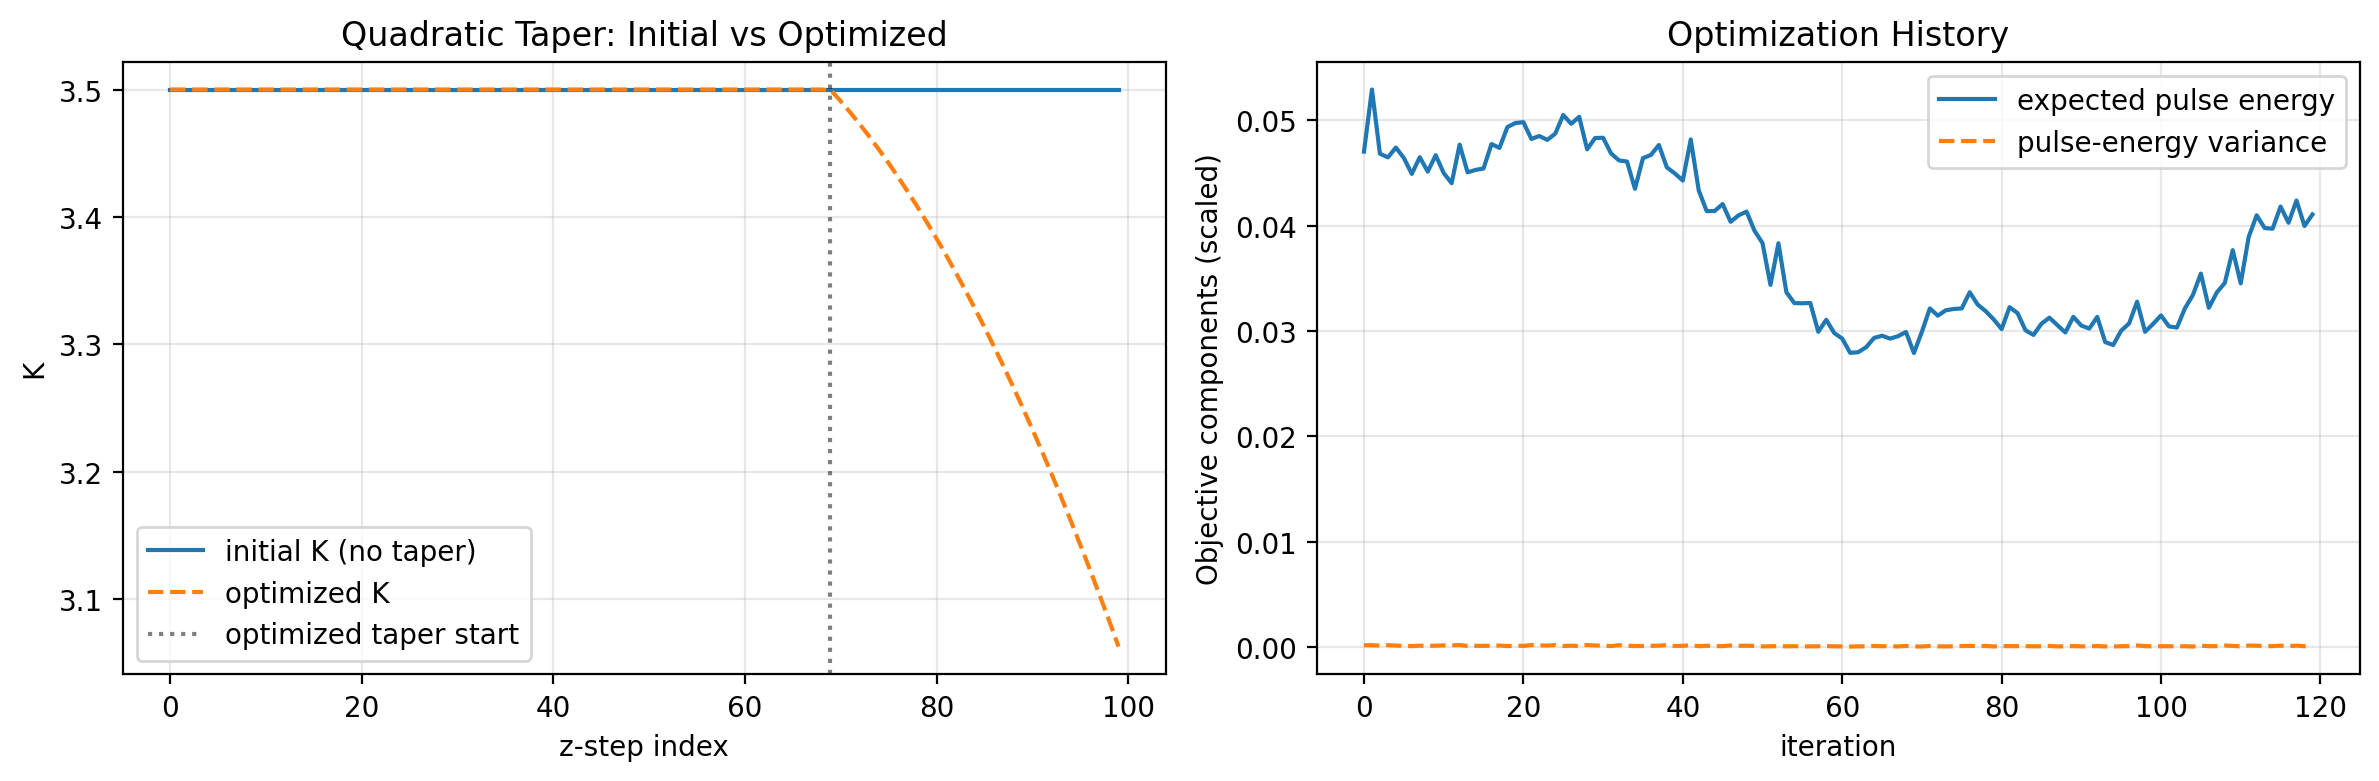

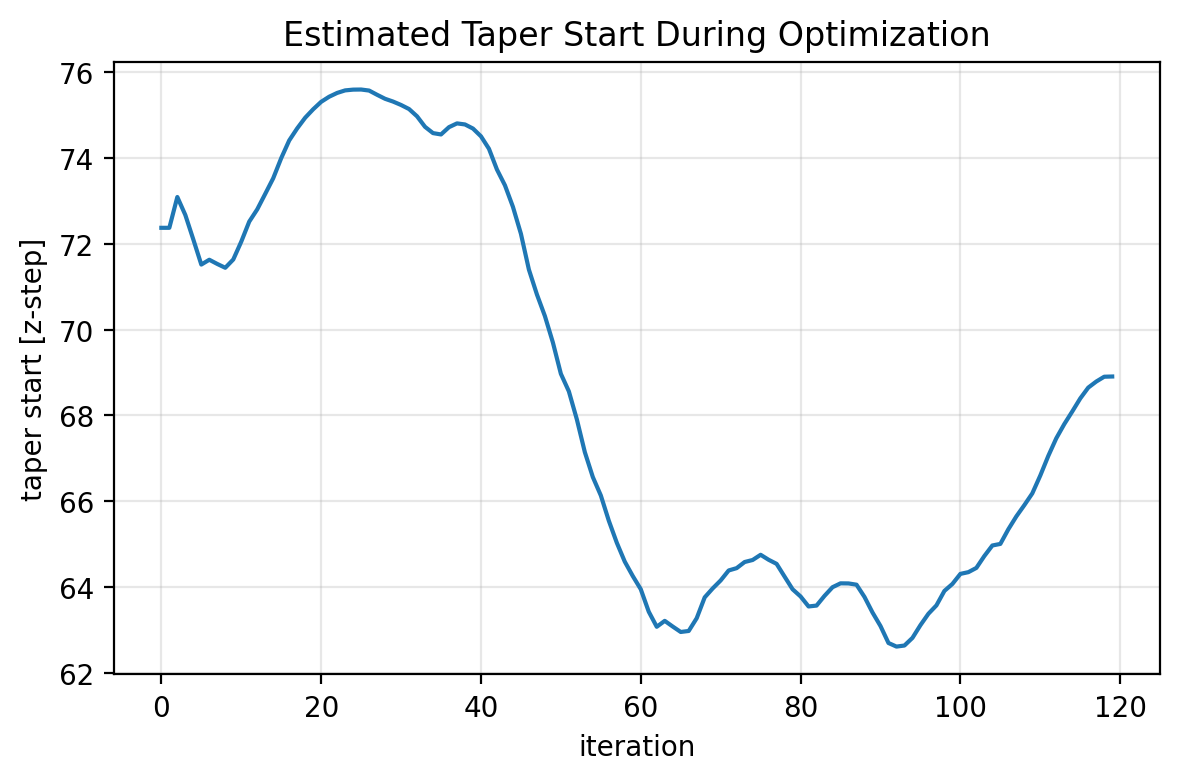

In [11]:
z_idx = np.arange(z_steps_opt)
start_line = float(start_final * (z_steps_opt - 1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(z_idx, np.asarray(K_init), label='initial K (no taper)')
ax[0].plot(z_idx, np.asarray(K_final), '--', label='optimized K')
ax[0].axvline(start_line, color='k', linestyle=':', alpha=0.5, label='optimized taper start')
ax[0].set_xlabel('z-step index')
ax[0].set_ylabel('K')
ax[0].set_title('Quadratic Taper: Initial vs Optimized')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(mean_hist, label='expected pulse energy')
ax[1].plot(var_hist, '--', label='pulse-energy variance')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('Objective components (scaled)')
ax[1].set_title('Optimization History')
ax[1].grid(alpha=0.3)
ax[1].legend()

fig.tight_layout()

# Save plots for reproducibility
os.makedirs('docs/examples/generated_plots', exist_ok=True)
fig.savefig('docs/examples/generated_plots/mc_opt_k_profile_and_history.png', dpi=150)

plt.figure(figsize=(6, 4))
plt.plot(start_hist)
plt.xlabel('iteration')
plt.ylabel('taper start [z-step]')
plt.title('Estimated Taper Start During Optimization')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('docs/examples/generated_plots/mc_opt_mean_var_history.png', dpi=150)
